In [51]:
!pip install adversarial-robustness-toolbox
!pip install scikit-learn
!pip install matplotlib
!pip install pillow
!pip install torch torchvision

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from art.estimators.classification import SklearnClassifier
from art.attacks.inference.model_inversion import MIFace
from art.estimators.classification import PyTorchClassifier

In [53]:
!tar -xvf att_faces.tar.Z

x orl_faces/
x orl_faces/README
x orl_faces/s1/
x orl_faces/s1/6.pgm
x orl_faces/s1/7.pgm
x orl_faces/s1/8.pgm
x orl_faces/s1/9.pgm
x orl_faces/s1/10.pgm
x orl_faces/s1/1.pgm
x orl_faces/s1/2.pgm
x orl_faces/s1/3.pgm
x orl_faces/s1/4.pgm
x orl_faces/s1/5.pgm
x orl_faces/s2/
x orl_faces/s2/6.pgm
x orl_faces/s2/7.pgm
x orl_faces/s2/8.pgm
x orl_faces/s2/9.pgm
x orl_faces/s2/10.pgm
x orl_faces/s2/1.pgm
x orl_faces/s2/2.pgm
x orl_faces/s2/3.pgm
x orl_faces/s2/4.pgm
x orl_faces/s2/5.pgm
x orl_faces/s3/
x orl_faces/s3/6.pgm
x orl_faces/s3/7.pgm
x orl_faces/s3/8.pgm
x orl_faces/s3/9.pgm
x orl_faces/s3/10.pgm
x orl_faces/s3/1.pgm
x orl_faces/s3/2.pgm
x orl_faces/s3/3.pgm
x orl_faces/s3/4.pgm
x orl_faces/s3/5.pgm
x orl_faces/s4/
x orl_faces/s4/6.pgm
x orl_faces/s4/7.pgm
x orl_faces/s4/8.pgm
x orl_faces/s4/9.pgm
x orl_faces/s4/10.pgm
x orl_faces/s4/1.pgm
x orl_faces/s4/2.pgm
x orl_faces/s4/3.pgm
x orl_faces/s4/4.pgm
x orl_faces/s4/5.pgm
x orl_faces/s5/
x orl_faces/s5/6.pgm
x orl_faces/s5/7.pgm
x 

Load dataset

In [54]:
data = []
labels = []
dataset_path = "orl_faces"
for person in sorted(os.listdir(dataset_path)):
    person_path = os.path.join(dataset_path, person)
    if not os.path.isdir(person_path):
        continue
    for img in sorted(os.listdir(person_path)):
        if not img.endswith(".pgm"):
            continue
        img_path = os.path.join(person_path, img)
        image = Image.open(img_path).convert("L")
        image = np.array(image)
        data.append(image.flatten())
        labels.append(person)
X = np.array(data)
y = np.array(labels)
print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Dataset Shape: (900, 10304)
Labels Shape: (900,)


In [55]:
X = X / 255.0

encoder = LabelEncoder()
y = encoder.fit_transform(y)

(np.float64(-0.5), np.float64(91.5), np.float64(111.5), np.float64(-0.5))

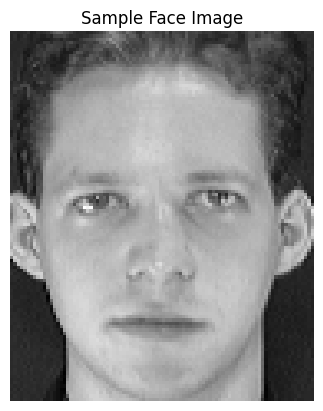

In [56]:
sample = X[0].reshape(112,92)

plt.imshow(sample, cmap="gray")
plt.title("Sample Face Image")
plt.axis("off")

Train Classifier

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [59]:
class FaceModel(nn.Module):
    def __init__(self):
        super(FaceModel, self).__init__()
        self.fc1 = nn.Linear(10304, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 40)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Train Model

In [60]:
model = FaceModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 3.686908721923828
Epoch: 5 Loss: 3.395432233810425
Epoch: 10 Loss: 2.9119722843170166
Epoch: 15 Loss: 2.3200159072875977


In [61]:
with torch.no_grad():

    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.6222222222222222


In [62]:
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(10304,),
    nb_classes=40
)

In [67]:
from art.attacks.inference.model_inversion import MIFace
attack = MIFace(classifier)
target_label = np.array([0])   # target person
reconstructed = attack.infer(x=X_train[:1], y=target_label)

Model inversion: 100%|██████████| 1/1 [00:00<00:00, 136.80it/s]


(np.float64(-0.5), np.float64(91.5), np.float64(111.5), np.float64(-0.5))

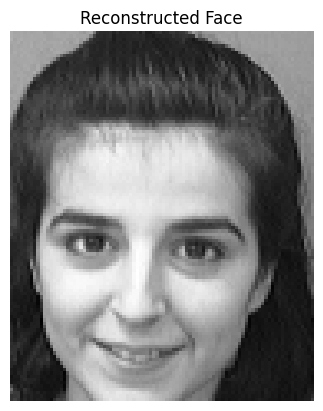

In [68]:
face = reconstructed[0].reshape(112,92)
plt.imshow(face, cmap="gray")
plt.title("Reconstructed Face")
plt.axis("off")